# Laptop Price Prediction

In [1]:
#First we need to import our required libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("laptop_data.csv")

In [3]:
df.head(10)

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080
5,5,Acer,Notebook,15.6,1366x768,AMD A9-Series 9420 3GHz,4GB,500GB HDD,AMD Radeon R5,Windows 10,2.1kg,21312.0000
6,6,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.2GHz,16GB,256GB Flash Storage,Intel Iris Pro Graphics,Mac OS X,2.04kg,114017.6016
7,7,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,256GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,61735.5360
8,8,Asus,Ultrabook,14.0,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,16GB,512GB SSD,Nvidia GeForce MX150,Windows 10,1.3kg,79653.6000
9,9,Acer,Ultrabook,14.0,IPS Panel Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8GB,256GB SSD,Intel UHD Graphics 620,Windows 10,1.6kg,41025.6000


**Price**

In [4]:
df['Price'].value_counts()

Price
58554.7200     14
79866.7200     14
95850.7200     14
26586.7200     11
63882.7200     11
               ..
26581.3920      1
130001.6016     1
18381.0672      1
20986.9920      1
41025.6000      1
Name: count, Length: 791, dtype: int64

/tmp/ipykernel_43142/834922981.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Price'])


<Axes: xlabel='Price', ylabel='Density'>

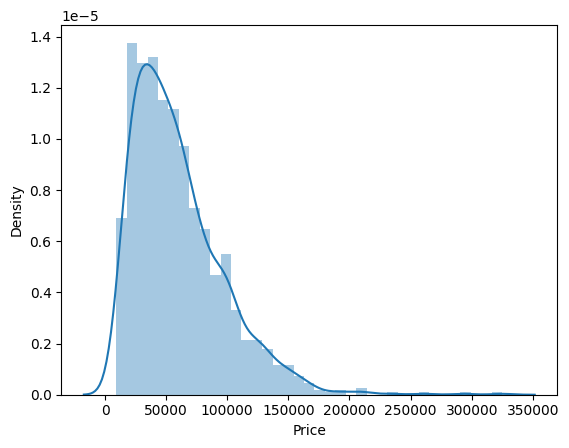

In [5]:
sns.distplot(df['Price'])

In [6]:
skew = df['Price'].skew()
print(f"Skewness of Price is : {skew}")

Skewness of Price is : 1.5208655681688517


**The Price is positively right skewed**

<Axes: xlabel='Price', ylabel='Count'>

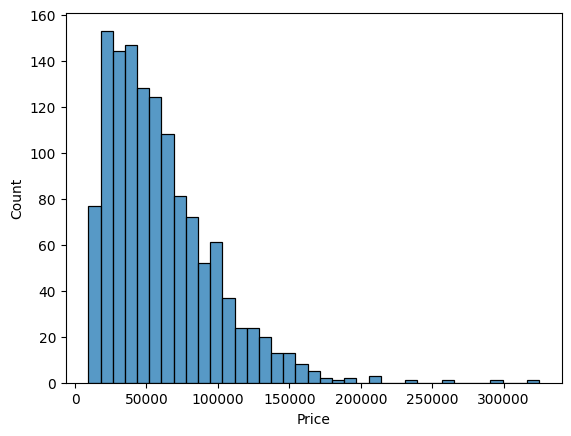

In [7]:
sns.histplot(df['Price'])

In [8]:
#First we removed unnamed column
df.drop(columns= ['Unnamed: 0'], inplace=True)

In [9]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [10]:
#Check the shape of dataset
df.shape

(1303, 11)

**Dataset Shape**:

1303 Rows and 11 Columns

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   object 
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   object 
 10  Price             1303 non-null   float64
dtypes: float64(2), object(9)
memory usage: 112.1+ KB


In [12]:
#Check the missing values
df.isnull().sum()

Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

# Univariate Analysis

**Company**

In [13]:
df['Company'].value_counts()

Company
Dell         297
Lenovo       297
HP           274
Asus         158
Acer         103
MSI           54
Toshiba       48
Apple         21
Samsung        9
Mediacom       7
Razer          7
Microsoft      6
Vero           4
Xiaomi         4
Chuwi          3
Fujitsu        3
Google         3
LG             3
Huawei         2
Name: count, dtype: int64

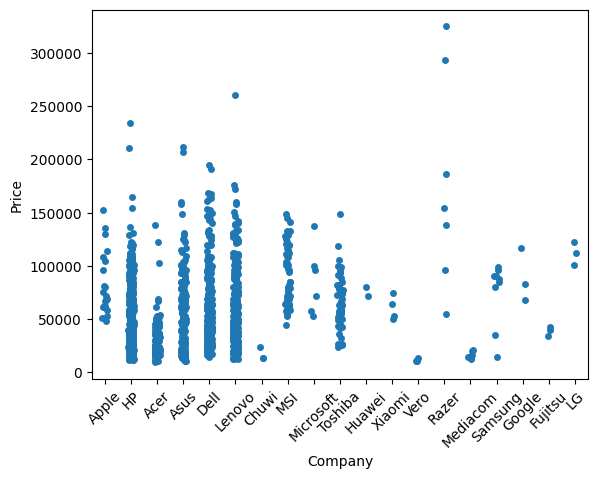

In [14]:
sns.stripplot(data=df, x='Company', y='Price', jitter=True)
plt.xticks(rotation=45)
plt.show()

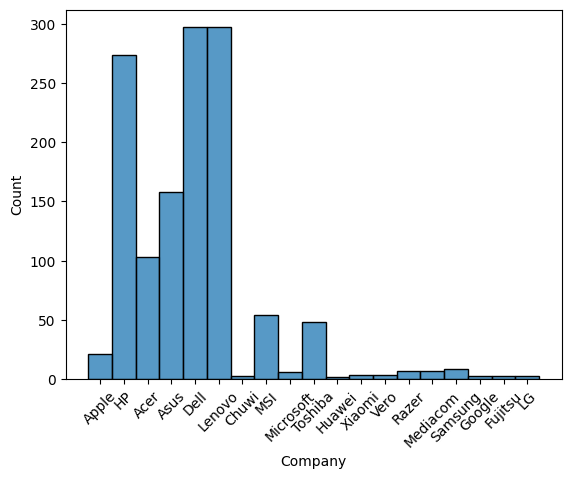

In [15]:
sns.histplot(data=df, x='Company')
plt.xticks(rotation=45) # Rotate by 45 or 90 degrees
plt.show()

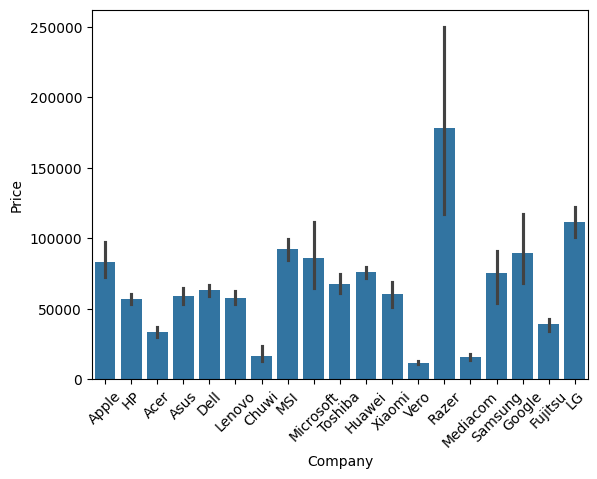

In [16]:
sns.barplot(data=df, x='Company', y='Price')
plt.xticks(rotation=45)
plt.show()

In [17]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


**TypeName**

In [18]:
vc = df['TypeName'].value_counts()
print(f"Total value counts of TypeName :")
print("="*40)
print(vc)

Total value counts of TypeName :
TypeName
Notebook              727
Gaming                205
Ultrabook             196
2 in 1 Convertible    121
Workstation            29
Netbook                25
Name: count, dtype: int64


<Axes: xlabel='TypeName'>

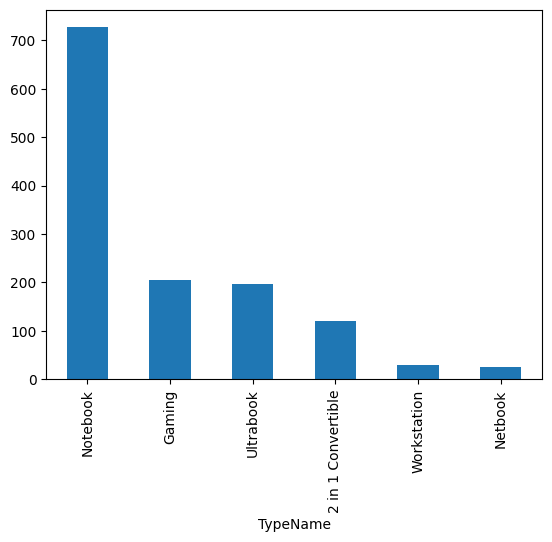

In [19]:
#put these value_count on barplot
df['TypeName'].value_counts().plot(kind='bar')

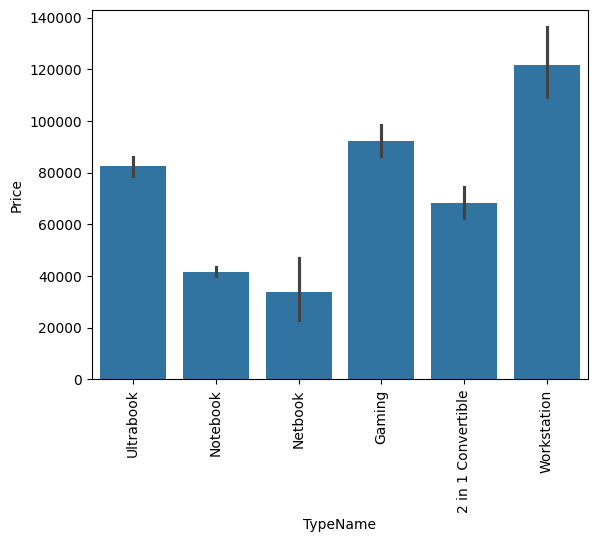

In [20]:
sns.barplot(x=df['TypeName'], y=df['Price'])
plt.xticks(rotation='vertical')
plt.show()

**Obervations**:

**Notebook:** Affordable prices

**Workstation, Ultrabook, Gaming:** High prices

In [21]:
df.head(10)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080
5,Acer,Notebook,15.6,1366x768,AMD A9-Series 9420 3GHz,4GB,500GB HDD,AMD Radeon R5,Windows 10,2.1kg,21312.0000
6,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.2GHz,16GB,256GB Flash Storage,Intel Iris Pro Graphics,Mac OS X,2.04kg,114017.6016
7,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,256GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,61735.5360
8,Asus,Ultrabook,14.0,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,16GB,512GB SSD,Nvidia GeForce MX150,Windows 10,1.3kg,79653.6000
9,Acer,Ultrabook,14.0,IPS Panel Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8GB,256GB SSD,Intel UHD Graphics 620,Windows 10,1.6kg,41025.6000


**Inches**

In [22]:
df['Inches'].value_counts()

Inches
15.6    665
14.0    197
13.3    164
17.3    164
12.5     39
11.6     33
13.5      6
12.0      6
13.9      6
12.3      5
10.1      4
15.4      4
15.0      4
13.0      2
18.4      1
17.0      1
14.1      1
11.3      1
Name: count, dtype: int64

/tmp/ipykernel_43142/1439577752.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Inches'])


<Axes: xlabel='Inches', ylabel='Density'>

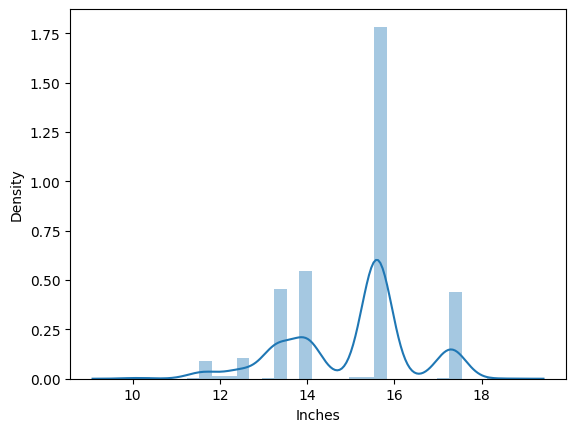

In [23]:
sns.distplot(df['Inches'])

<Axes: xlabel='Inches', ylabel='Price'>

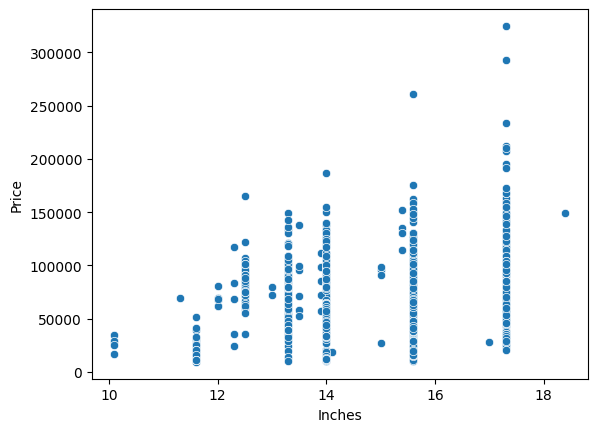

In [24]:
sns.scatterplot(x=df['Inches'], y = df['Price'])

In [25]:
df.head(5)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [26]:
df['Ram'] = df['Ram'].str.replace('GB', '')
df['Weight'] = df['Weight'].str.replace('kg', '')

In [27]:
df['Ram'] = df['Ram'].astype('int32')
df['Weight'] = df['Weight'].astype('float32')

In [28]:
df.head(5)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080


In [29]:
df['Ram'].value_counts()

Ram
8     619
4     375
16    200
6      41
12     25
2      22
32     17
24      3
64      1
Name: count, dtype: int64

/tmp/ipykernel_43142/863594587.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Ram'])


<Axes: xlabel='Ram', ylabel='Density'>

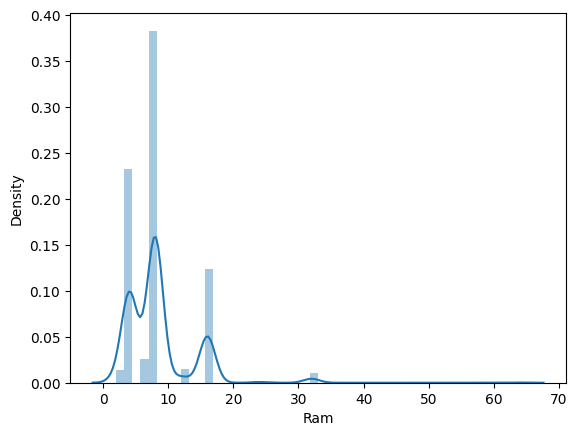

In [30]:
sns.distplot(df['Ram'])

<Axes: xlabel='Ram', ylabel='Price'>

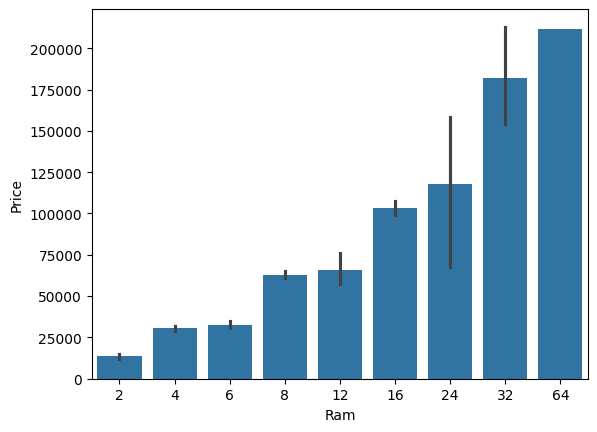

In [31]:
sns.barplot(x=df['Ram'], y=df['Price'])

In [32]:
df['Weight'].value_counts().sort_values(ascending=False)

Weight
2.200    126
2.100     58
2.000     45
2.400     44
2.300     41
        ... 
0.990      1
2.591      1
2.210      1
2.191      1
2.340      1
Name: count, Length: 171, dtype: int64

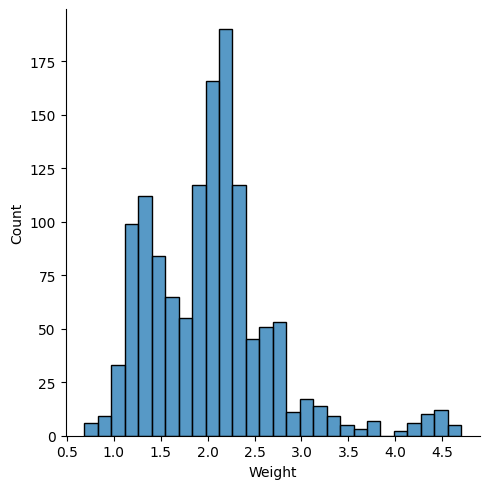

In [33]:
sns.displot(df['Weight'])

<Axes: xlabel='Weight', ylabel='Price'>

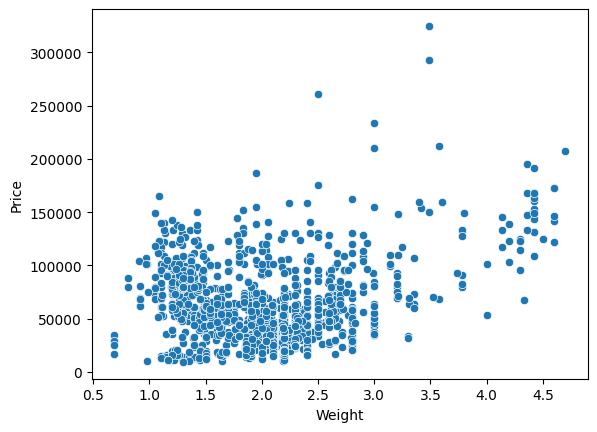

In [34]:
sns.scatterplot(x=df['Weight'], y=df['Price'])

In [35]:
data = df[df['Weight']>3.00]

<Axes: xlabel='Weight', ylabel='Price'>

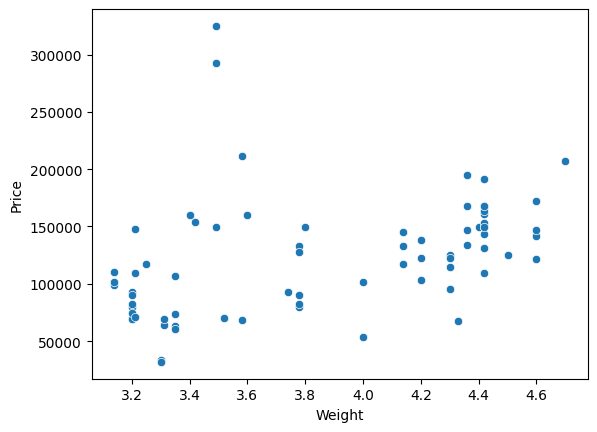

In [36]:
sns.scatterplot(x=data['Weight'], y= data['Price'])

**So as we see most of the laptop weight greate 3kg are gaming and workstation laptops**

In [37]:
correlation = df['Price'].corr(df['Weight'])
print(correlation)

0.21036980196834215


**The correlation b/w weight and price are not very good**

In [38]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080


**ScreenResolution**

In [39]:
df['ScreenResolution'].value_counts()

ScreenResolution
Full HD 1920x1080                                507
1366x768                                         281
IPS Panel Full HD 1920x1080                      230
IPS Panel Full HD / Touchscreen 1920x1080         53
Full HD / Touchscreen 1920x1080                   47
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  15
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160               10
IPS Panel 1366x768                                 7
Touchscreen 2560x1440                              7
4K Ultra HD 3840x2160                              7
IPS Panel Retina Display 2304x1440                 6
IPS Panel Retina Display 2560x1600                 6
Touchscreen 2256x1504                              6
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
IPS Panel Touchscreen 2560x14

In [40]:
df['TouchScreen'] = df['ScreenResolution'].apply(lambda x:1 if 'Touchscreen' in x else 0)

In [41]:
df.sample(10)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen
874,Samsung,Ultrabook,15.0,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,16,256GB SSD,Nvidia GeForce 940MX,Windows 10,1.23,98514.7200,0
616,Dell,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,4,128GB SSD,AMD Radeon R5 M420,Linux,2.18,30316.3200,0
790,Asus,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8,128GB SSD + 1TB HDD,Nvidia GeForce GTX1060,Windows 10,2.24,71341.9200,0
583,Dell,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7600U 2.8GHz,16,256GB SSD,Nvidia GeForce 930MX,Windows 10,1.93,81912.1392,0
487,Dell,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16,512GB SSD,Nvidia GeForce GTX 1050,Windows 10,2.06,101178.7200,0
1174,Lenovo,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8,1TB HDD,Nvidia GeForce 940MX,No OS,2.20,37775.5200,0
858,Dell,Notebook,13.3,Full HD / Touchscreen 1920x1080,Intel Core i5 6200U 2.3GHz,8,1TB HDD,Intel HD Graphics 520,Windows 10,1.62,34578.7200,1
372,Asus,Gaming,17.3,IPS Panel Full HD 1920x1080,AMD Ryzen 1700 3GHz,16,256GB SSD + 1TB HDD,AMD Radeon RX 580,Windows 10,3.25,117162.7200,0
1155,HP,Notebook,15.6,Full HD 1920x1080,AMD A6-Series A6-9220 2.5GHz,4,256GB SSD,AMD Radeon 520,Windows 10,1.91,25515.2592,0
1136,HP,Workstation,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,8,256GB SSD,Nvidia Quadro M3000M,Windows 7,3.00,210424.0320,0


In [42]:
df['IPS'] = df['ScreenResolution'].apply(lambda x:1 if 'IPS' in x else 0)

In [43]:
df.sample(10)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS
177,MSI,Gaming,18.4,Full HD 1920x1080,Intel Core i7 6920HQ 2.9GHz,32,512GB SSD + 1TB HDD,Nvidia GTX 980 SLI,Windows 10,4.40,149130.7200,0,0
1047,MSI,Gaming,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 6820HK 2.7GHz,16,256GB SSD + 1TB HDD,Nvidia GeForce GTX 980M,Windows 10,3.78,82351.6992,0,1
360,HP,Notebook,15.6,1366x768,Intel Core i3 6006U 2GHz,4,500GB HDD,Intel HD Graphics 520,Windows 10,1.86,23389.9200,0,0
756,HP,Notebook,15.6,IPS Panel Full HD 1920x1080,Intel Core i5 7300HQ 2.5GHz,8,128GB SSD + 1TB HDD,Nvidia GeForce GTX 1050,Windows 10,2.20,58554.7200,0,1
730,Acer,Gaming,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16,128GB SSD + 1TB HDD,Nvidia GeForce GTX 1060,Windows 10,4.20,103096.8000,0,1
1142,HP,2 in 1 Convertible,13.3,Full HD / Touchscreen 1920x1080,Intel Core i5 6300U 2.4GHz,8,256GB SSD,Intel HD Graphics 520,Windows 10,1.48,86793.1200,1,0
850,HP,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4,128GB SSD,Intel HD Graphics 400,No OS,1.86,15930.7200,0,0
625,Lenovo,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8,1TB HDD,Nvidia GeForce 920MX,Windows 10,2.20,47898.7200,0,0
908,Lenovo,Notebook,15.6,IPS Panel Full HD 1920x1080,Intel Core i5 6300HQ 2.3GHz,8,128GB SSD + 1TB HDD,Nvidia GeForce GTX 960M,Windows 10,2.60,42037.9200,0,1
926,Lenovo,Ultrabook,12.5,IPS Panel Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8,256GB SSD,Intel HD Graphics 620,Windows 10,1.36,87912.0000,0,1


In [44]:
new = df['ScreenResolution'].str.split('x',n=1, expand = True)

In [45]:
df['x_res'] = new[0]
df['y_res'] = new[1]


In [46]:
# Ye har row ke aakhri word (2560) ko nikal lega
df['x_res']=df['x_res'].str.split().str[-1]


In [47]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,x_res,y_res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560,1600


<Axes: xlabel='TouchScreen', ylabel='Price'>

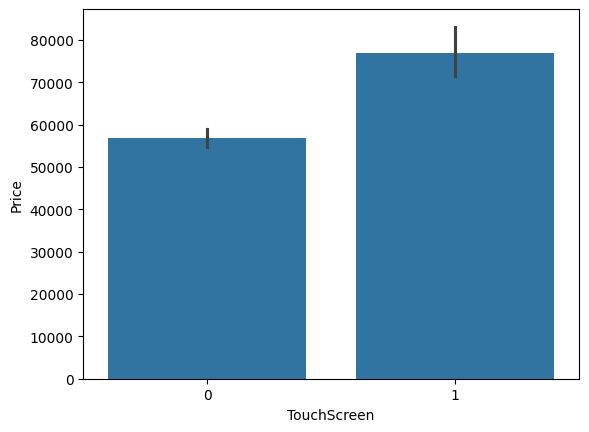

In [48]:
sns.barplot(x=df["TouchScreen"], y= df['Price'])

<Axes: xlabel='IPS', ylabel='Price'>

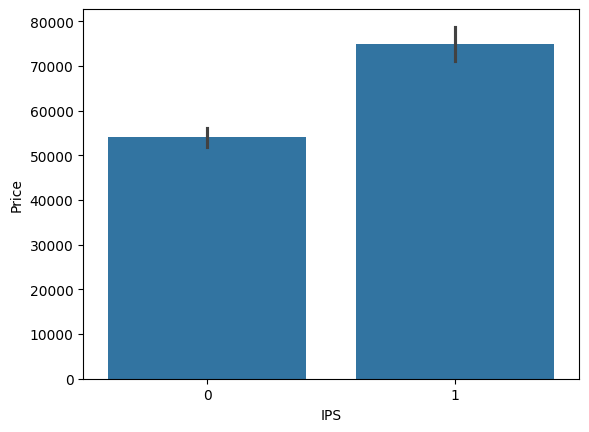

In [49]:
sns.barplot(x=df["IPS"], y= df['Price'])

In [50]:
df['x_res'] = df['x_res'].astype(int)
df['y_res'] = df['y_res'].astype(int)

In [51]:
df['ppi'] = ((df['x_res']**2)+(df['y_res']**2))**0.5/(df['Inches']).astype(float)

In [52]:
df.drop(columns=['ScreenResolution'],inplace=True)

In [53]:
df.drop(columns=['Inches','x_res','y_res'],inplace=True)

In [54]:
df.head(5)

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,ppi
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005


In [55]:
df['OpSys'].value_counts()

OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         27
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

In [56]:
def cat_os(inp):
    if inp == 'Windows 10' or inp == 'Windows 7' or inp == 'Windows 10 S':
        return 'Windows'
    elif inp == 'macOS' or inp == 'Mac OS X':
        return 'Mac'
    else:
        return 'Others/No OS/Linux'

In [57]:


df['OpSys'] = df['OpSys'].apply(cat_os)

In [58]:
df['OpSys'].nunique()

3

<Axes: xlabel='OpSys', ylabel='Price'>

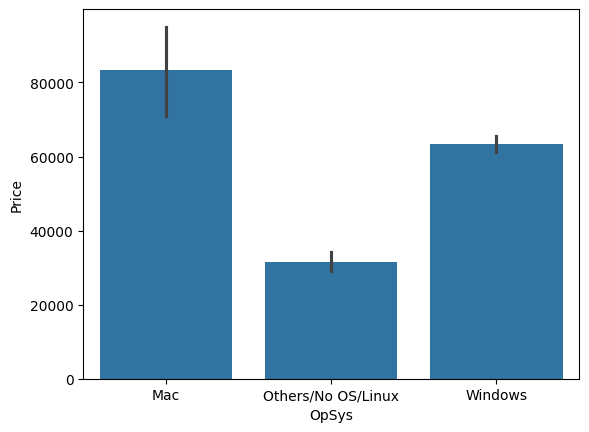

In [59]:
sns.barplot(x=df['OpSys'], y=df['Price'])

In [60]:
df.head(10)

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,ppi
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,Mac,1.37,71378.6832,0,1,226.983005
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,Mac,1.34,47895.5232,0,0,127.677940
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,Others/No OS/Linux,1.86,30636.0000,0,0,141.211998
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,Mac,1.83,135195.3360,0,1,220.534624
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,Mac,1.37,96095.8080,0,1,226.983005
5,Acer,Notebook,AMD A9-Series 9420 3GHz,4,500GB HDD,AMD Radeon R5,Windows,2.10,21312.0000,0,0,100.454670
6,Apple,Ultrabook,Intel Core i7 2.2GHz,16,256GB Flash Storage,Intel Iris Pro Graphics,Mac,2.04,114017.6016,0,1,220.534624
7,Apple,Ultrabook,Intel Core i5 1.8GHz,8,256GB Flash Storage,Intel HD Graphics 6000,Mac,1.34,61735.5360,0,0,127.677940
8,Asus,Ultrabook,Intel Core i7 8550U 1.8GHz,16,512GB SSD,Nvidia GeForce MX150,Windows,1.30,79653.6000,0,0,157.350512
9,Acer,Ultrabook,Intel Core i5 8250U 1.6GHz,8,256GB SSD,Intel UHD Graphics 620,Windows,1.60,41025.6000,0,1,157.350512


In [61]:
df['Cpu'].value_counts()

Cpu
Intel Core i5 7200U 2.5GHz       190
Intel Core i7 7700HQ 2.8GHz      146
Intel Core i7 7500U 2.7GHz       134
Intel Core i7 8550U 1.8GHz        73
Intel Core i5 8250U 1.6GHz        72
                                ... 
Intel Core i5 7200U 2.70GHz        1
Intel Core M M7-6Y75 1.2GHz        1
Intel Core M 6Y54 1.1GHz           1
AMD E-Series 9000 2.2GHz           1
Samsung Cortex A72&A53 2.0GHz      1
Name: count, Length: 118, dtype: int64

In [62]:
df['Cpu_name'] = df['Cpu'].apply(lambda x: " ".join(x.split()[0:3]))

In [63]:
def processor_find(text):
    if text =="Intel Core i7" or text == "Intel Core i5" or text == "Intel Core i3":
        return text
    else:
        if text.split()[0] == "Intel":
           return "Other Intel Processor"
        else:
            return "AMD Processor"

In [64]:
df['Cpu_brand'] = df['Cpu_name'].apply(processor_find)

In [65]:
df.sample(10)

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,ppi,Cpu_name,Cpu_brand
555,Asus,Notebook,Intel Celeron Dual Core N3350 1.1GHz,4,500GB HDD,Intel HD Graphics 500,Others/No OS/Linux,2.00,11934.7200,0,0,100.454670,Intel Celeron Dual,Other Intel Processor
1082,Lenovo,2 in 1 Convertible,Intel Atom x5-Z8550 1.44GHz,4,64GB Flash Storage,Intel HD Graphics 400,Windows,0.69,34433.2656,1,1,224.173809,Intel Atom x5-Z8550,Other Intel Processor
510,Dell,Ultrabook,Intel Core i5 7200U 2.5GHz,8,128GB SSD,Intel HD Graphics 620,Windows,1.29,47898.7200,1,1,165.632118,Intel Core i5,Intel Core i5
1156,MSI,Gaming,Intel Core i7 7700HQ 2.8GHz,16,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1050 Ti,Windows,2.70,79536.3840,0,0,127.335675,Intel Core i7,Intel Core i7
698,Toshiba,Ultrabook,Intel Core i7 6500U 2.5GHz,16,512GB SSD,Intel HD Graphics 520,Windows,1.36,100006.5600,1,0,165.632118,Intel Core i7,Intel Core i7
160,Asus,Notebook,AMD A9-Series 9420 3GHz,4,1TB HDD,AMD Radeon R5 M420,Windows,2.03,21471.8400,0,0,100.454670,AMD A9-Series 9420,AMD Processor
795,Lenovo,2 in 1 Convertible,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,Windows,1.42,124142.4000,1,1,209.800683,Intel Core i5,Intel Core i5
545,HP,Notebook,Intel Core i3 7100U 2.4GHz,4,128GB SSD,Intel HD Graphics 620,Windows,2.10,37589.0400,0,0,141.211998,Intel Core i3,Intel Core i3
1209,Asus,Gaming,Intel Core i7 7700HQ 2.8GHz,16,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows,2.20,130482.7200,0,0,141.211998,Intel Core i7,Intel Core i7
620,HP,Notebook,Intel Core i5 7300U 2.6GHz,8,256GB SSD,Intel HD Graphics 620,Windows,2.31,59886.7200,0,0,111.935204,Intel Core i5,Intel Core i5


<Axes: xlabel='Cpu_brand', ylabel='count'>

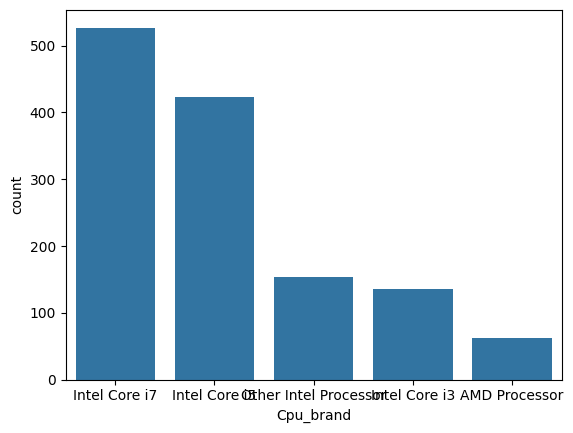

In [66]:
sns.barplot(df["Cpu_brand"].value_counts())

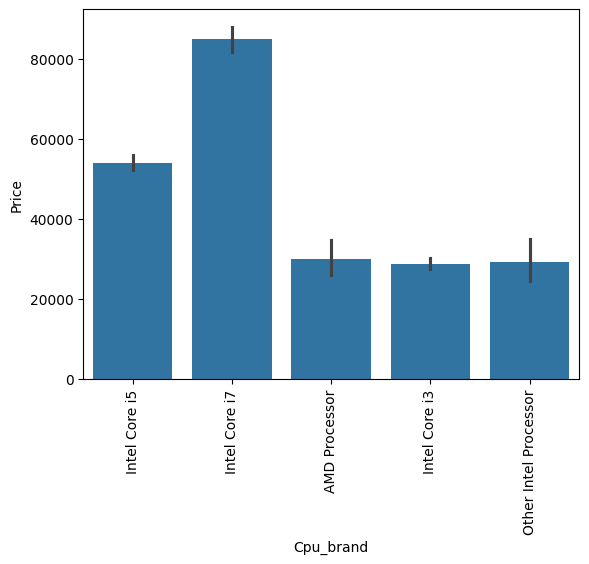

In [67]:
sns.barplot(x=df["Cpu_brand"], y = df['Price'])
plt.xticks(rotation='vertical')
plt.show()

In [68]:
df.drop(columns=['Cpu', 'Cpu_name'], inplace=True)

In [69]:
df.sample(15)

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,ppi,Cpu_brand
420,Lenovo,2 in 1 Convertible,16,512GB SSD,Nvidia GeForce GTX 1050,Windows,2.00,101178.72,1,1,282.423996,Intel Core i7
1270,Lenovo,2 in 1 Convertible,4,128GB SSD,Intel HD Graphics 520,Windows,1.80,33992.64,1,1,157.350512,Intel Core i7
565,Dell,Ultrabook,8,128GB SSD,Intel UHD Graphics 620,Windows,1.21,85194.72,1,1,331.264236,Intel Core i5
153,MSI,Gaming,16,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1060,Windows,2.80,100699.20,0,0,127.335675,Intel Core i7
47,Asus,Gaming,8,256GB SSD + 1TB HDD,AMD Radeon RX 580,Windows,3.20,69210.72,0,0,127.335675,AMD Processor
191,Vero,Notebook,4,32GB Flash Storage,Intel HD Graphics 500,Windows,1.30,13852.80,0,1,157.350512,Other Intel Processor
1037,Toshiba,Ultrabook,8,256GB SSD,Intel HD Graphics 520,Windows,1.47,91908.00,0,1,157.350512,Intel Core i7
972,Dell,Gaming,32,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows,4.42,149184.00,0,0,127.335675,Intel Core i7
736,HP,Workstation,16,256GB SSD,Nvidia Quadro M2200,Windows,2.60,128884.32,0,0,141.211998,Intel Core i7
846,HP,2 in 1 Convertible,4,32GB Flash Storage,Intel HD Graphics 500,Others/No OS/Linux,1.40,32767.20,1,0,135.094211,Other Intel Processor


In [70]:
df["Gpu_brand"] = df['Gpu'].apply(lambda x:x.split()[0])

In [71]:
df.head(10)

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,ppi,Cpu_brand,Gpu_brand
0,Apple,Ultrabook,8,128GB SSD,Intel Iris Plus Graphics 640,Mac,1.37,71378.6832,0,1,226.983005,Intel Core i5,Intel
1,Apple,Ultrabook,8,128GB Flash Storage,Intel HD Graphics 6000,Mac,1.34,47895.5232,0,0,127.677940,Intel Core i5,Intel
2,HP,Notebook,8,256GB SSD,Intel HD Graphics 620,Others/No OS/Linux,1.86,30636.0000,0,0,141.211998,Intel Core i5,Intel
3,Apple,Ultrabook,16,512GB SSD,AMD Radeon Pro 455,Mac,1.83,135195.3360,0,1,220.534624,Intel Core i7,AMD
4,Apple,Ultrabook,8,256GB SSD,Intel Iris Plus Graphics 650,Mac,1.37,96095.8080,0,1,226.983005,Intel Core i5,Intel
5,Acer,Notebook,4,500GB HDD,AMD Radeon R5,Windows,2.10,21312.0000,0,0,100.454670,AMD Processor,AMD
6,Apple,Ultrabook,16,256GB Flash Storage,Intel Iris Pro Graphics,Mac,2.04,114017.6016,0,1,220.534624,Intel Core i7,Intel
7,Apple,Ultrabook,8,256GB Flash Storage,Intel HD Graphics 6000,Mac,1.34,61735.5360,0,0,127.677940,Intel Core i5,Intel
8,Asus,Ultrabook,16,512GB SSD,Nvidia GeForce MX150,Windows,1.30,79653.6000,0,0,157.350512,Intel Core i7,Nvidia
9,Acer,Ultrabook,8,256GB SSD,Intel UHD Graphics 620,Windows,1.60,41025.6000,0,1,157.350512,Intel Core i5,Intel


In [72]:
df['Gpu_brand'].value_counts()

Gpu_brand
Intel     722
Nvidia    400
AMD       180
ARM         1
Name: count, dtype: int64

In [73]:
df = df[df["Gpu_brand"] != "ARM"]

In [74]:
df['Gpu_brand'].value_counts()

Gpu_brand
Intel     722
Nvidia    400
AMD       180
Name: count, dtype: int64

In [75]:
df.head(10)

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,ppi,Cpu_brand,Gpu_brand
0,Apple,Ultrabook,8,128GB SSD,Intel Iris Plus Graphics 640,Mac,1.37,71378.6832,0,1,226.983005,Intel Core i5,Intel
1,Apple,Ultrabook,8,128GB Flash Storage,Intel HD Graphics 6000,Mac,1.34,47895.5232,0,0,127.677940,Intel Core i5,Intel
2,HP,Notebook,8,256GB SSD,Intel HD Graphics 620,Others/No OS/Linux,1.86,30636.0000,0,0,141.211998,Intel Core i5,Intel
3,Apple,Ultrabook,16,512GB SSD,AMD Radeon Pro 455,Mac,1.83,135195.3360,0,1,220.534624,Intel Core i7,AMD
4,Apple,Ultrabook,8,256GB SSD,Intel Iris Plus Graphics 650,Mac,1.37,96095.8080,0,1,226.983005,Intel Core i5,Intel
5,Acer,Notebook,4,500GB HDD,AMD Radeon R5,Windows,2.10,21312.0000,0,0,100.454670,AMD Processor,AMD
6,Apple,Ultrabook,16,256GB Flash Storage,Intel Iris Pro Graphics,Mac,2.04,114017.6016,0,1,220.534624,Intel Core i7,Intel
7,Apple,Ultrabook,8,256GB Flash Storage,Intel HD Graphics 6000,Mac,1.34,61735.5360,0,0,127.677940,Intel Core i5,Intel
8,Asus,Ultrabook,16,512GB SSD,Nvidia GeForce MX150,Windows,1.30,79653.6000,0,0,157.350512,Intel Core i7,Nvidia
9,Acer,Ultrabook,8,256GB SSD,Intel UHD Graphics 620,Windows,1.60,41025.6000,0,1,157.350512,Intel Core i5,Intel


In [76]:
df.drop(columns=['Gpu'], inplace=True)

In [77]:
df.sample(15)

,Company,TypeName,Ram,Memory,OpSys,Weight,Price,TouchScreen,IPS,ppi,Cpu_brand,Gpu_brand
683,HP,Notebook,4,256GB SSD,Windows,2.50,37242.7200,0,1,127.335675,Intel Core i3,AMD
1139,HP,Ultrabook,8,256GB SSD,Windows,1.88,115709.2416,0,0,141.211998,Intel Core i7,Intel
1040,Lenovo,2 in 1 Convertible,4,256GB SSD,Windows,1.80,45128.1600,1,1,141.211998,Intel Core i7,Intel
628,Asus,2 in 1 Convertible,6,1TB HDD,Windows,1.50,34046.4528,1,0,165.632118,Intel Core i5,Intel
1129,HP,Gaming,8,128GB SSD + 1TB HDD,Windows,3.35,60153.1200,0,1,127.335675,Intel Core i5,Nvidia
694,Toshiba,Notebook,8,256GB SSD,Windows,1.50,51841.4400,0,1,165.632118,Intel Core i5,Intel
819,Dell,Notebook,4,500GB HDD,Windows,1.76,40226.4000,0,0,111.935204,Intel Core i5,Intel
140,Acer,Notebook,4,1TB HDD,Windows,3.00,34898.4000,0,1,127.335675,Intel Core i3,Nvidia
259,Lenovo,2 in 1 Convertible,8,512GB SSD,Windows,2.00,90522.7200,1,1,141.211998,Intel Core i7,Nvidia
147,Asus,Notebook,4,1TB HDD,Windows,2.00,18328.3200,0,0,141.211998,Other Intel Processor,Intel


In [78]:
df['Memory'] = df['Memory'].astype(str).replace('\.0', '', regex=True)
df['Memory'] = df['Memory'].str.replace('GB', '')
df['Memory'] = df['Memory'].str.replace('TB', '000')
new = df['Memory'].str.split("+", n=1, expand=True)
df['first'] = new[0]
df['first'] = df['first'].str.strip()
df['second'] = new[1]

df["layer1HDD"] = df['first'].apply(lambda x: 1 if "HDD" in x else 0)
df["layer1SSD"] = df['first'].apply(lambda x: 1 if "SSD" in x else 0)
df["layer1Hybrid"] = df['first'].apply(lambda x: 1 if "Hybrid" in x else 0)
df['layer1Flash_Storage'] = df['first'].apply(lambda x: 1 if "Flash Storage" in x else 0)
df['first'] = df['first'].str.replace(r'\D', '', regex=True)
df["second"].fillna("0", inplace = True)

df["Layer2HDD"] = df["second"].apply(lambda x: 1 if "HDD" in x else 0)
df["Layer2SSD"] = df["second"].apply(lambda x: 1 if "SSD" in x else 0)
df["Layer2Hybrid"] = df["second"].apply(lambda x: 1 if "Hybrid" in x else 0)
df["Layer2Flash_Storage"] = df["second"].apply(lambda x: 1 if "Flash Storage" in x else 0)

df['second'] = df['second'].str.replace(r'\D', '', regex=True)

df["first"] = df["first"].astype(int)
df["second"] = df["second"].astype(int)

/tmp/ipykernel_43142/2729550346.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["second"].fillna("0", inplace = True)


In [79]:
df["HDD"]=(df["first"]*df["layer1HDD"]+df["second"]*df["Layer2HDD"])
df["SSD"]=(df["first"]*df["layer1SSD"]+df["second"]*df["Layer2SSD"])
df["Hybrid"]=(df["first"]*df["layer1Hybrid"]+df["second"]*df["Layer2Hybrid"])
df["Flash_Storage"]=(df["first"]*df["layer1Flash_Storage"]+df["second"]*df["Layer2Flash_Storage"])


In [80]:
df.drop(columns=['first', 'second', 'layer1HDD', 'layer1SSD', 'layer1Hybrid',
       'layer1Flash_Storage', 'Layer2HDD', 'Layer2SSD', 'Layer2Hybrid',
       'Layer2Flash_Storage'],inplace=True)

In [81]:
df.sample(10)

,Company,TypeName,Ram,Memory,OpSys,Weight,Price,TouchScreen,IPS,ppi,Cpu_brand,Gpu_brand,HDD,SSD,Hybrid,Flash_Storage
972,Dell,Gaming,32,256 SSD + 1000 HDD,Windows,4.42,149184.0000,0,0,127.335675,Intel Core i7,Nvidia,1000,256,0,0
709,HP,Notebook,6,2000 HDD,Windows,2.71,34898.9328,0,1,127.335675,AMD Processor,AMD,2000,0,0,0
1241,Asus,Ultrabook,8,256 SSD,Windows,1.45,68198.4000,0,0,165.632118,Intel Core i7,Intel,0,256,0,0
94,Asus,Ultrabook,8,256 SSD,Windows,1.25,55890.7200,0,0,157.350512,Intel Core i7,Intel,0,256,0,0
483,Chuwi,Notebook,4,64 Flash Storage,Windows,1.89,13261.3920,0,0,141.211998,Other Intel Processor,Intel,0,0,0,64
489,Asus,Ultrabook,16,512 SSD,Windows,0.91,103896.0000,0,0,176.232574,Intel Core i7,Intel,0,512,0,0
459,HP,Notebook,8,256 SSD,Windows,2.50,34093.8720,0,0,106.113062,Intel Core i3,Intel,0,256,0,0
326,Acer,Notebook,6,1000 HDD,Windows,2.23,29250.7200,0,0,100.454670,Intel Core i5,Intel,1000,0,0,0
942,Acer,Notebook,4,500 HDD,Windows,2.23,32980.3200,0,0,100.454670,Intel Core i5,Intel,500,0,0,0
644,Acer,Notebook,4,500 HDD,Windows,2.40,23976.0000,0,0,100.454670,Intel Core i3,Intel,500,0,0,0


In [82]:
df.drop(columns=['Memory'], inplace=True)

In [83]:
df.head(10)

,Company,TypeName,Ram,OpSys,Weight,Price,TouchScreen,IPS,ppi,Cpu_brand,Gpu_brand,HDD,SSD,Hybrid,Flash_Storage
0,Apple,Ultrabook,8,Mac,1.37,71378.6832,0,1,226.983005,Intel Core i5,Intel,0,128,0,0
1,Apple,Ultrabook,8,Mac,1.34,47895.5232,0,0,127.677940,Intel Core i5,Intel,0,0,0,128
2,HP,Notebook,8,Others/No OS/Linux,1.86,30636.0000,0,0,141.211998,Intel Core i5,Intel,0,256,0,0
3,Apple,Ultrabook,16,Mac,1.83,135195.3360,0,1,220.534624,Intel Core i7,AMD,0,512,0,0
4,Apple,Ultrabook,8,Mac,1.37,96095.8080,0,1,226.983005,Intel Core i5,Intel,0,256,0,0
5,Acer,Notebook,4,Windows,2.10,21312.0000,0,0,100.454670,AMD Processor,AMD,500,0,0,0
6,Apple,Ultrabook,16,Mac,2.04,114017.6016,0,1,220.534624,Intel Core i7,Intel,0,0,0,256
7,Apple,Ultrabook,8,Mac,1.34,61735.5360,0,0,127.677940,Intel Core i5,Intel,0,0,0,256
8,Asus,Ultrabook,16,Windows,1.30,79653.6000,0,0,157.350512,Intel Core i7,Nvidia,0,512,0,0
9,Acer,Ultrabook,8,Windows,1.60,41025.6000,0,1,157.350512,Intel Core i5,Intel,0,256,0,0


In [84]:
df.corr(numeric_only=True)['Price']

Ram              0.742905
Weight           0.209867
Price            1.000000
TouchScreen      0.192917
IPS              0.253320
ppi              0.475368
HDD             -0.096891
SSD              0.670660
Hybrid           0.007942
Flash_Storage   -0.040067
Name: Price, dtype: float64

In [85]:
df.drop(columns=['Hybrid', "Flash_Storage"], inplace=True)

<Axes: >

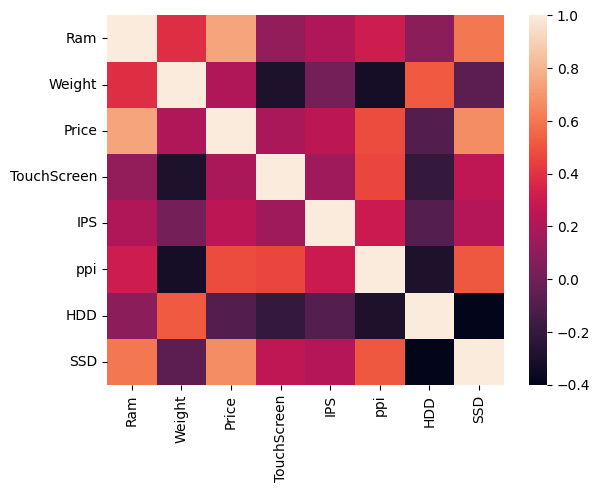

In [86]:
sns.heatmap(df.corr(numeric_only=True))

/tmp/ipykernel_43142/3556049916.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.log(df['Price']))


<Axes: xlabel='Price', ylabel='Density'>

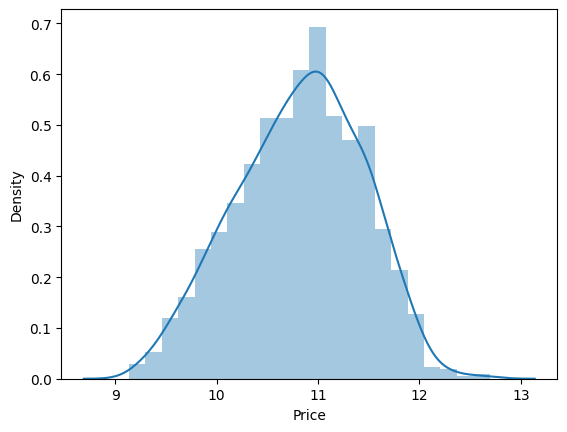

In [87]:
sns.distplot(np.log(df['Price']))

In [88]:
X = df.drop(columns=['Price'])
y = np.log(df['Price'])

# Start Model Training

In [89]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.15,random_state=2)

In [90]:
X_train

,Company,TypeName,Ram,OpSys,Weight,TouchScreen,IPS,ppi,Cpu_brand,Gpu_brand,HDD,SSD
183,Toshiba,Notebook,8,Windows,2.00,0,0,100.454670,Intel Core i5,Intel,0,128
1141,MSI,Gaming,8,Windows,2.40,0,0,141.211998,Intel Core i7,Nvidia,1000,128
1049,Asus,Netbook,4,Others/No OS/Linux,1.20,0,0,135.094211,Other Intel Processor,Intel,0,0
1020,Dell,2 in 1 Convertible,4,Windows,2.08,1,1,141.211998,Intel Core i3,Intel,1000,0
878,Dell,Notebook,4,Windows,2.18,0,0,141.211998,Intel Core i5,Nvidia,1000,128
...,...,...,...,...,...,...,...,...,...,...,...,...
466,Acer,Notebook,4,Windows,2.20,0,0,100.454670,Intel Core i3,Nvidia,500,0
299,Asus,Ultrabook,16,Windows,1.63,0,0,141.211998,Intel Core i7,Nvidia,0,512
493,Acer,Notebook,8,Windows,2.20,0,0,100.454670,AMD Processor,AMD,1000,0
527,Lenovo,Notebook,8,Others/No OS/Linux,2.20,0,0,100.454670,Intel Core i3,Nvidia,2000,0


In [91]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score, mean_absolute_error

In [92]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,AdaBoostRegressor,ExtraTreesRegressor
from sklearn.svm import SVR
#from xgboost import XGBRegressor

**Linear Regression**

In [93]:
step1 = ColumnTransformer(
    transformers=[
        ('col_tnf', OneHotEncoder(sparse_output=False,drop='first'),[0,1,3,8,9])
    ],remainder='passthrough'
)
step2 = LinearRegression()

pipe = Pipeline([
    ('step1',step1),
    ('step2',step2)
])

pipe.fit(X_train, y_train)
y_pred =pipe.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.8073277448418614
MAE 0.21017827976428774


**Ridge Regression**

In [94]:
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,3,8,9])
],remainder='passthrough')

step2 = Ridge(alpha=10)

pipe = Pipeline([
    ('step1',step1),
    ('step2',step2)
])

pipe.fit(X_train,y_train)

y_pred = pipe.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.8127331031311809
MAE 0.20926802242582976


**Lasso Regression**

In [95]:
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,3,8,9])
],remainder='passthrough')

step2 = Lasso(alpha=0.001)

pipe = Pipeline([
    ('step1',step1),
    ('step2',step2)
])

pipe.fit(X_train,y_train)

y_pred = pipe.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.8071857196899417
MAE 0.2111435071691317


**KNN**

In [96]:
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,3,8,9])
],remainder='passthrough')

step2 = KNeighborsRegressor(n_neighbors=3)

pipe = Pipeline([
    ('step1',step1),
    ('step2',step2)
])

pipe.fit(X_train,y_train)

y_pred = pipe.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.803148868705085
MAE 0.19264883332948868


**Decision Tree**

In [97]:
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,3,8,9])
],remainder='passthrough')

step2 = DecisionTreeRegressor(max_depth=8)

pipe = Pipeline([
    ('step1',step1),
    ('step2',step2)
])

pipe.fit(X_train,y_train)

y_pred = pipe.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.8415299407162091
MAE 0.18031853295938244


**SVM**

In [98]:
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,3,8,9])
],remainder='passthrough')

step2 = SVR(kernel='rbf',C=10000,epsilon=0.1)

pipe = Pipeline([
    ('step1',step1),
    ('step2',step2)
])

pipe.fit(X_train,y_train)

y_pred = pipe.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.8083180902272435
MAE 0.20239059427315706


**Random Forest**

In [99]:
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,3,8,9])
],remainder='passthrough')

step2 = RandomForestRegressor(n_estimators=100,
                              random_state=3,
                              max_samples=0.5,
                              max_features=0.75,
                              max_depth=15)

pipe = Pipeline([
    ('step1',step1),
    ('step2',step2)
])

pipe.fit(X_train,y_train)

y_pred = pipe.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.8851499847098487
MAE 0.15870252595141304


**ExtraTrees**

In [100]:
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,3,8,9])
],remainder='passthrough')

step2 = ExtraTreesRegressor(
    n_estimators=100,
    random_state=3,
    max_samples=0.5,
    max_features=0.75,
    max_depth=15,
    bootstrap=True)

pipe = Pipeline([
    ('step1',step1),
    ('step2',step2)
])

pipe.fit(X_train,y_train)

y_pred = pipe.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.8889027931156277
MAE 0.16030477745273902


**AdaBoost**

In [101]:
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,3,8,9])
],remainder='passthrough')

step2 = AdaBoostRegressor(n_estimators=15,learning_rate=1.0)
pipe = Pipeline([
    ('step1',step1),
    ('step2',step2)
])

pipe.fit(X_train,y_train)

y_pred = pipe.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.7918280948454659
MAE 0.22968217329514995


**Gradient Boost**

In [102]:
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,3,8,9])
],remainder='passthrough')

step2 = GradientBoostingRegressor(n_estimators=500)
pipe = Pipeline([
    ('step1',step1),
    ('step2',step2)
])

pipe.fit(X_train,y_train)

y_pred = pipe.predict(X_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.88322039637038
MAE 0.15902767281440214


**XGboost**

**Exporting the Model**

In [103]:
import pickle

pickle.dump(df,open('df.pkl','wb'))
pickle.dump(pipe,open('pipe.pkl','wb'))

In [104]:
X_train

,Company,TypeName,Ram,OpSys,Weight,TouchScreen,IPS,ppi,Cpu_brand,Gpu_brand,HDD,SSD
183,Toshiba,Notebook,8,Windows,2.00,0,0,100.454670,Intel Core i5,Intel,0,128
1141,MSI,Gaming,8,Windows,2.40,0,0,141.211998,Intel Core i7,Nvidia,1000,128
1049,Asus,Netbook,4,Others/No OS/Linux,1.20,0,0,135.094211,Other Intel Processor,Intel,0,0
1020,Dell,2 in 1 Convertible,4,Windows,2.08,1,1,141.211998,Intel Core i3,Intel,1000,0
878,Dell,Notebook,4,Windows,2.18,0,0,141.211998,Intel Core i5,Nvidia,1000,128
...,...,...,...,...,...,...,...,...,...,...,...,...
466,Acer,Notebook,4,Windows,2.20,0,0,100.454670,Intel Core i3,Nvidia,500,0
299,Asus,Ultrabook,16,Windows,1.63,0,0,141.211998,Intel Core i7,Nvidia,0,512
493,Acer,Notebook,8,Windows,2.20,0,0,100.454670,AMD Processor,AMD,1000,0
527,Lenovo,Notebook,8,Others/No OS/Linux,2.20,0,0,100.454670,Intel Core i3,Nvidia,2000,0
